# Analysis of data by INGV

- Earthquake Frequency over year
- Magnitude Distribution over year
- Depth Distribution over year
- Relationship Between Depth and Magnitude

Loading the filtered Italian dataset...
Dataset ready: 216097 earthquakes loaded.


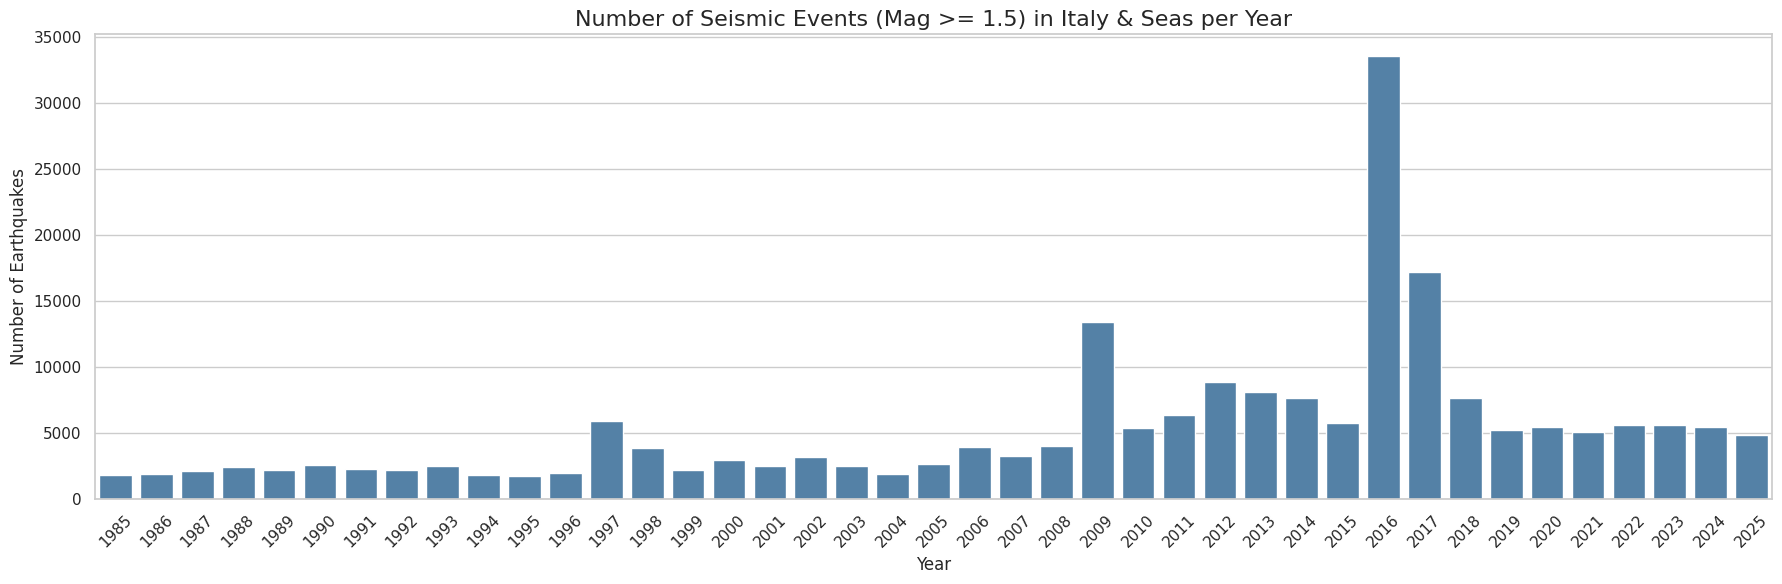

/tmp/ipykernel_7747/1280226437.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='year', y='magnitude', palette='viridis')


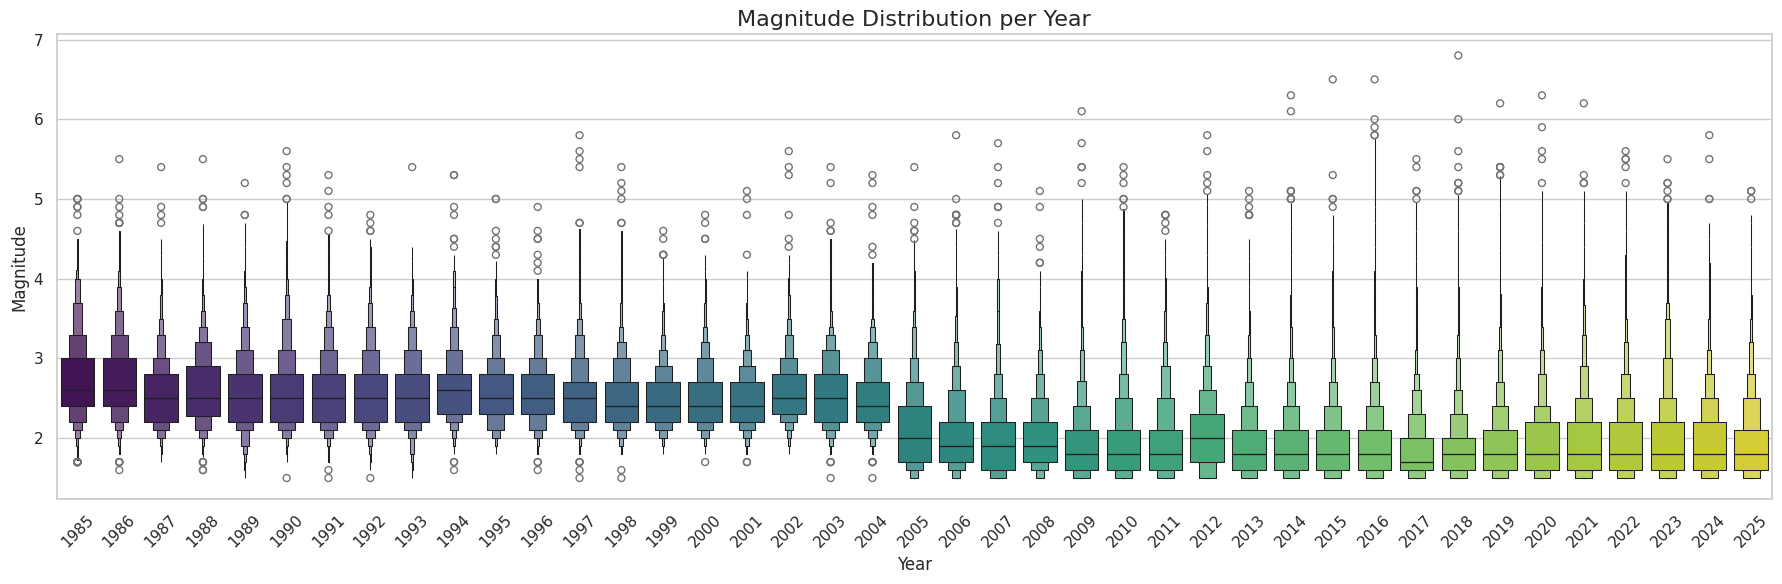

/tmp/ipykernel_7747/1280226437.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year', y='depth/km', palette='magma')


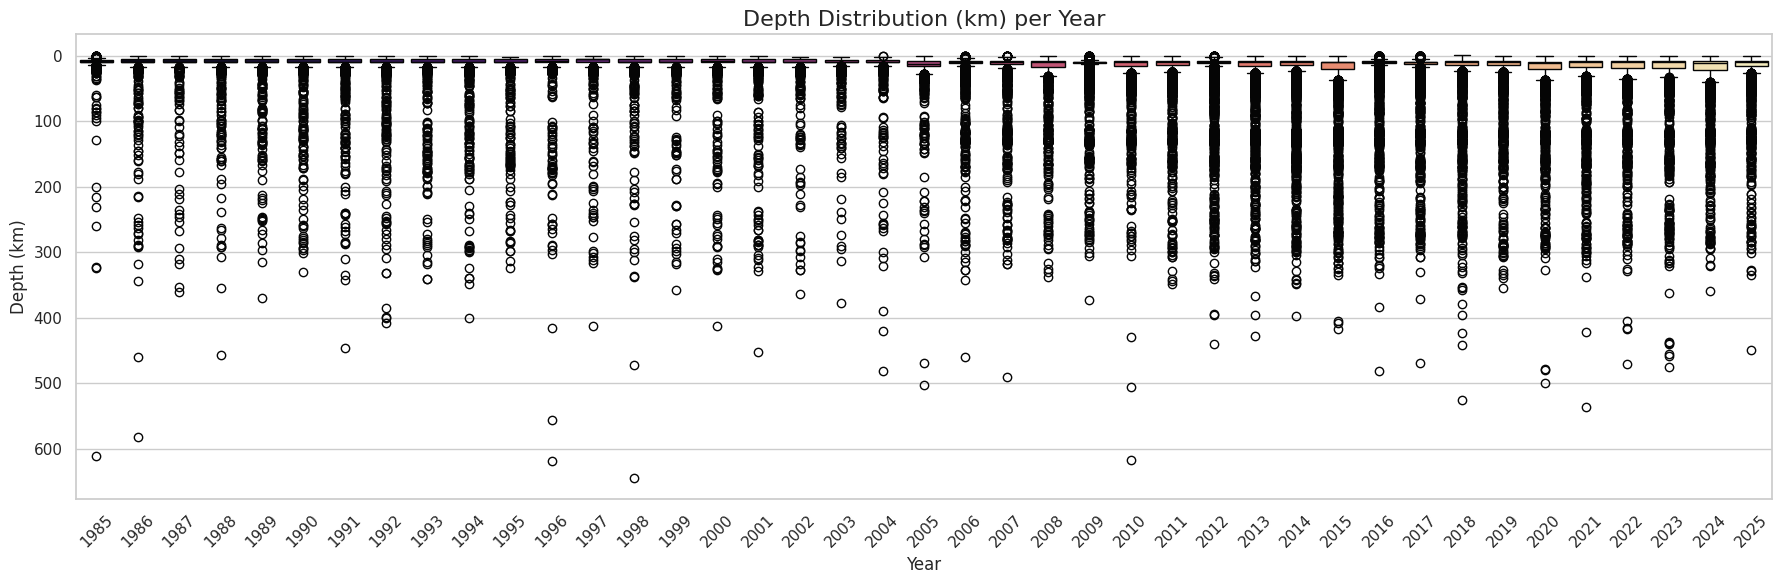

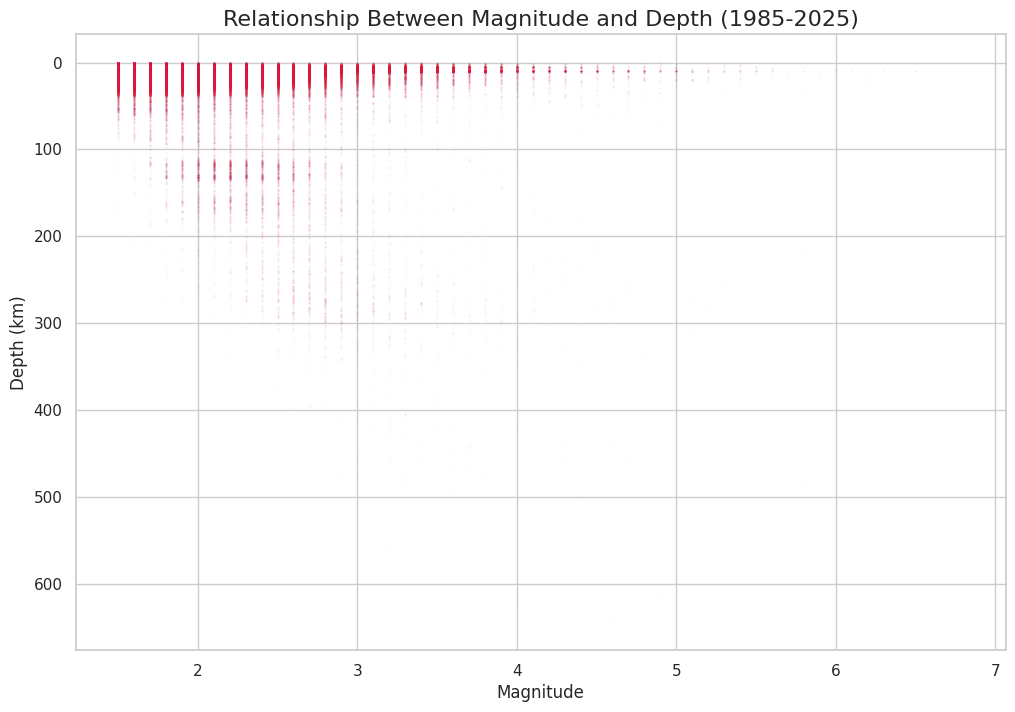

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the visual style
sns.set_theme(style="whitegrid")
%matplotlib inline

# 2. Load the clean, filtered dataset
print("Loading the filtered Italian dataset...")
df = pd.read_csv("data/INGV/ingv_raw_earthquakes_1985_2025_complete.csv")

# Ensure 'time' is a datetime object and extract the year
df['time'] = pd.to_datetime(df['time'], utc=True)
df['year'] = df['time'].dt.year

print(f"Dataset ready: {len(df)} earthquakes loaded.")

# ==========================================
# PLOT 1: Earthquake Frequency Over Time
# ==========================================
plt.figure(figsize=(18, 6))
# Using a bar plot counting years
year_counts = df['year'].value_counts().sort_index()
sns.barplot(x=year_counts.index, y=year_counts.values, color='steelblue')
plt.xticks(rotation=45)
plt.title('Number of Seismic Events (Mag >= 1.5) in Italy & Seas per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.tight_layout()
plt.show()

# ==========================================
# PLOT 2: Magnitude Distribution per Year
# ==========================================
plt.figure(figsize=(18, 6))
# We use boxenplot (or violinplot) instead of boxplot for large datasets 
# to better visualize the shape of the distribution with many outliers
sns.boxenplot(data=df, x='year', y='magnitude', palette='viridis')
plt.xticks(rotation=45)
plt.title('Magnitude Distribution per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

# ==========================================
# PLOT 3: Depth Distribution per Year
# ==========================================
plt.figure(figsize=(18, 6))
sns.boxplot(data=df, x='year', y='depth/km', palette='magma')
# Invert the Y-axis to simulate underground depth (0 at the surface)
plt.gca().invert_yaxis() 
plt.xticks(rotation=45)
plt.title('Depth Distribution (km) per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Depth (km)')
plt.tight_layout()
plt.show()

# ==========================================
# PLOT 4: Relationship Between Depth and Magnitude
# ==========================================
plt.figure(figsize=(12, 8))
# With 200k points, we need very small markers (s=2) and high transparency (alpha=0.05)
sns.scatterplot(data=df, x='magnitude', y='depth/km', alpha=0.05, s=2, color='crimson')
plt.gca().invert_yaxis()
plt.title('Relationship Between Magnitude and Depth (1985-2025)', fontsize=16)
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.show()

## Interactive visualization of map with data 

In [2]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'iframe' 

# 1. Load the filtered dataset
print("Loading data for map visualization...")
df = pd.read_csv("data/INGV/ingv_raw_earthquakes_1985_2025_complete.csv")

# 2. Filter for performance and clarity
df_map = df[df['magnitude'] >= 3.0].copy()
print(f"Plotting {len(df_map)} significant earthquakes (Mag >= 3.0)...")

# 3. Create the interactive Mapbox scatter plot
fig = px.scatter_mapbox(
    df_map, 
    lat="latitude", 
    lon="longitude", 
    color="magnitude",
    size="magnitude",
    color_continuous_scale="matter",
    zoom=4.5,
    center={"lat": 41.9, "lon": 12.5},
    mapbox_style="carto-positron",
    hover_name="time",
    hover_data={
        "latitude": ":.3f", 
        "longitude": ":.3f", 
        "depth/km": True,
        "magnitude": True
    },
    title="Interactive Seismic Map: Italy & Territorial Waters (Mag >= 3.0)"
)

# 4. Adjust layout margins and display
fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
fig.show()

Loading data for map visualization...
Plotting 15422 significant earthquakes (Mag >= 3.0)...


/tmp/ipykernel_7747/1060920689.py:16: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


## ***Gutenberg-Richter Law (2005-2025)***

<>:51: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:51: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_7747/1101245875.py:51: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.ylabel('$\log_{10} N (\geq M)$', fontsize=14)


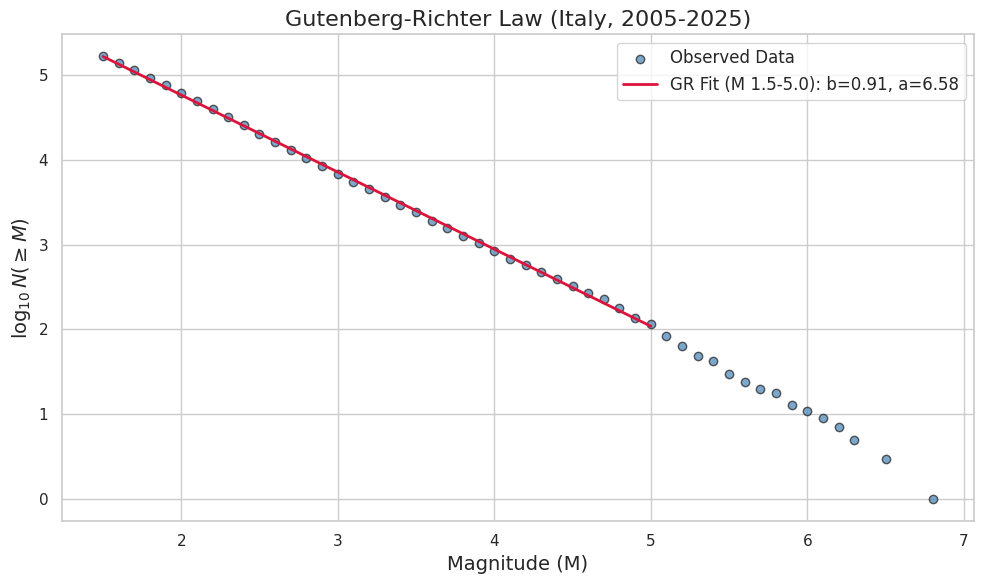

Calculated b-value: 0.909 (R-squared: 1.000)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Load and prepare the data (Post-2005 for completeness)
df = pd.read_csv("data/INGV/ingv_raw_earthquakes_1985_2025_complete.csv")
df['time'] = pd.to_datetime(df['time'], utc=True)
df_net = df[df['time'].dt.year >= 2005].copy()

# 2. Calculate Cumulative Frequencies
# Count how many earthquakes occurred for each magnitude
mag_counts = df_net['magnitude'].value_counts().sort_index()

# Calculate N: Cumulative sum from highest magnitude down to the lowest
cumulative_N = mag_counts[::-1].cumsum()[::-1]

# 3. Fit the GR Line (log10 N = a - bM)
# We only fit the linear part of the curve (Magnitude of Completeness ~1.5 up to ~5.0)
# Beyond 5.0, data is too sparse (finite-size effect). Below 1.5, the catalog is incomplete.
M_c = 1.5
max_fit_mag = 5.0

fit_mask = (cumulative_N.index >= M_c) & (cumulative_N.index <= max_fit_mag)
mags_for_fit = cumulative_N.index[fit_mask]
logN_for_fit = np.log10(cumulative_N.values[fit_mask])

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(mags_for_fit, logN_for_fit)
b_value = -slope # In GR, b is the negative of the slope
a_value = intercept

# 4. Plotting
plt.figure(figsize=(10, 6))

# Plot actual data
plt.scatter(cumulative_N.index, np.log10(cumulative_N.values), 
            color='steelblue', alpha=0.7, edgecolors='k', label='Observed Data')

# Plot the fitted GR Line
fit_line = a_value - b_value * mags_for_fit
plt.plot(mags_for_fit, fit_line, color='crimson', linewidth=2, 
         label=f'GR Fit (M {M_c}-{max_fit_mag}): b={b_value:.2f}, a={a_value:.2f}')

plt.title('Gutenberg-Richter Law (Italy, 2005-2025)', fontsize=16)
plt.xlabel('Magnitude (M)', fontsize=14)
plt.ylabel('$\log_{10} N (\geq M)$', fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"Calculated b-value: {b_value:.3f} (R-squared: {r_value**2:.3f})")
# A b-value around 1.0 indicates a perfectly normal tectonic environment!

## ***Omori Law: Aftershock Decay on Amatrice 2016 )***

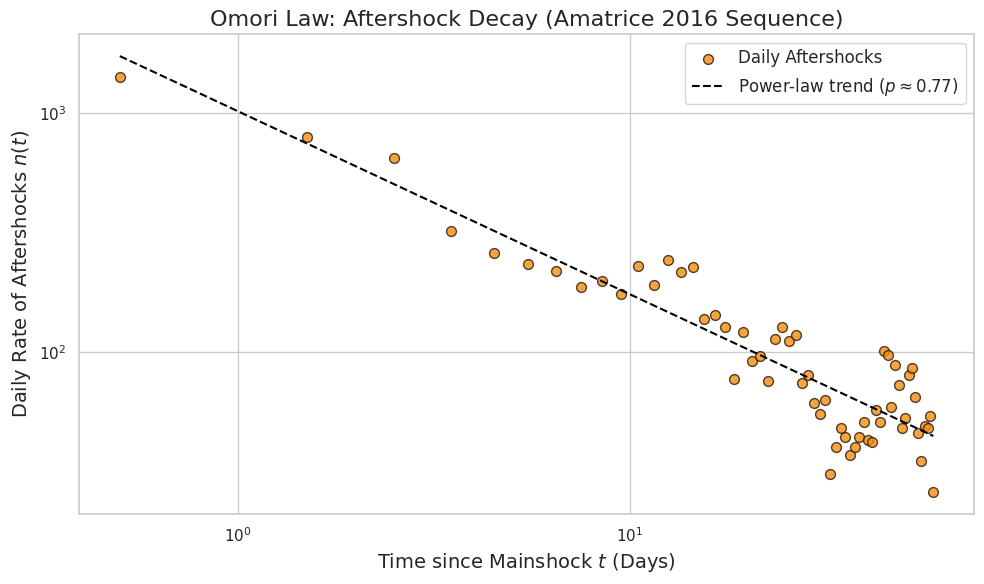

In [4]:
# 1. Isolate the Amatrice 2016 Sequence
mainshock_time = pd.to_datetime('2016-08-24 01:36:32', utc=True) # Exact time of Amatrice MS
end_time = mainshock_time + pd.Timedelta(days=60) # Look at 60 days of aftershocks

# Filter by time and space (a bounding box around Central Italy)
df_amatrice = df_net[
    (df_net['time'] >= mainshock_time) & 
    (df_net['time'] <= end_time) &
    (df_net['latitude'] >= 42.0) & (df_net['latitude'] <= 43.5) &
    (df_net['longitude'] >= 12.5) & (df_net['longitude'] <= 14.0)
].copy()

# Calculate time difference in days since the mainshock for each event
df_amatrice['days_since_mainshock'] = (df_amatrice['time'] - mainshock_time).dt.total_seconds() / (24 * 3600)

# 2. Calculate daily rate (n(t))
# We create bins of 1 day and count the number of earthquakes in each bin
bins = np.arange(0, 61, 1)
daily_counts, bin_edges = np.histogram(df_amatrice['days_since_mainshock'], bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Remove days with 0 counts to allow logarithmic plotting
mask = daily_counts > 0
t_valid = bin_centers[mask]
n_t_valid = daily_counts[mask]

# 3. Log-Log Plotting
plt.figure(figsize=(10, 6))

# In a log-log plot, the Omori decay should look like a straight descending line
plt.scatter(t_valid, n_t_valid, color='darkorange', alpha=0.8, edgecolors='k', s=50, label='Daily Aftershocks')

# Fit a simple line in log-log space to visualize the power-law slope (p-value in Omori)
log_t = np.log10(t_valid)
log_n = np.log10(n_t_valid)
slope, intercept, _, _, _ = linregress(log_t, log_n)
p_value = -slope

plt.plot(t_valid, 10**(intercept + slope * log_t), color='black', linestyle='--', 
         label=fr'Power-law trend ($p \approx {p_value:.2f}$)')

plt.xscale('log')
plt.yscale('log')
plt.title('Omori Law: Aftershock Decay (Amatrice 2016 Sequence)', fontsize=16)
plt.xlabel('Time since Mainshock $t$ (Days)', fontsize=14)
plt.ylabel('Daily Rate of Aftershocks $n(t)$', fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()